In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df= pd.read_csv(r"E:\engg\Data\marketing_campaign_data_messy.csv")
df

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


In [4]:
df_clean= df.copy(deep=True)

In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


In [6]:
df_clean.isnull().sum()

 Campaign_ID        0
Campaign_Name       0
Start_Date          0
End_Date            0
Channel           101
Impressions         0
Clicks              0
Spend               0
Conversions       200
Active              0
Clicks           1980
Campaign_Tag        0
dtype: int64

In [7]:
df_clean['Start_Date'] = pd.to_datetime(df_clean['Start_Date'],format="mixed").dt.strftime('%Y-%m-%d')

In [8]:
df_clean['Start_Date']

0       2023-11-24
1       2023-05-06
2       2023-12-13
3       2023-10-30
4       2023-04-22
           ...    
2015    2023-10-31
2016    2023-09-01
2017    2023-02-09
2018    2023-03-30
2019    2023-06-26
Name: Start_Date, Length: 2020, dtype: object

In [9]:
df_clean['End_Date']= pd.to_datetime(df['End_Date']).dt.strftime('%Y-%m-%d')
df_clean['End_Date']

0       2023-12-13
1       2023-05-12
2       2023-12-20
3       2023-11-03
4       2023-04-23
           ...    
2015    2023-11-13
2016    2023-09-26
2017    2023-02-21
2018    2023-04-27
2019    2023-07-09
Name: End_Date, Length: 2020, dtype: object

In [10]:
df_clean = df_clean.drop_duplicates(subset=' Campaign_ID ', keep='first')
df_clean.rename(columns={' Campaign_ID ': 'Campaign_ID'})

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CMP-01996,Q2_BlackFriday_CMP-01996,2023-06-25,2023-07-12,Google Ads,71316,2276,3144.16,184.0,1,NaN,GO
1996,CMP-01997,Q4_Winter_CMP-01997,2023-12-06,2023-12-18,Facebook,84847,2616,4528.0,449.0,0,NaN,FA
1997,CMP-01998,Q4_BlackFriday_CMP-01998,2023-12-31,2024-01-14,Instagram,29380,705,767.32,NaN,False,NaN,IN
1998,CMP-01999,Q1_Launch_CMP-01999,2023-10-31,2023-11-24,Instagram,3356,124,145.24,18.0,0,NaN,IN


In [11]:
df_clean[' Campaign_ID '].duplicated().sum()

np.int64(0)

In [12]:
df["Channel"] = df["Channel"].astype("string")


In [13]:
df["Channel"] = df["Channel"].fillna("Unknown")

In [14]:
df_clean

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CMP-01996,Q2_BlackFriday_CMP-01996,2023-06-25,2023-07-12,Google Ads,71316,2276,3144.16,184.0,1,NaN,GO
1996,CMP-01997,Q4_Winter_CMP-01997,2023-12-06,2023-12-18,Facebook,84847,2616,4528.0,449.0,0,NaN,FA
1997,CMP-01998,Q4_BlackFriday_CMP-01998,2023-12-31,2024-01-14,Instagram,29380,705,767.32,NaN,False,NaN,IN
1998,CMP-01999,Q1_Launch_CMP-01999,2023-10-31,2023-11-24,Instagram,3356,124,145.24,18.0,0,NaN,IN


In [15]:
df_clean['Spend'] = df_clean['Spend'].str.replace('$', '', regex=False)
df_clean['Spend'] = df_clean['Spend'].astype(float)

In [16]:
df_clean.columns

Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks',
       'Campaign_Tag'],
      dtype='object')

In [17]:
df_clean.drop(columns=['Clicks'], inplace=True)

In [18]:
df_clean['Conversions'] = (
    df_clean['Conversions']
    .replace('Unknown', np.nan)
)

df_clean['Conversions'] = pd.to_numeric(df_clean['Conversions'])

In [19]:
df_clean['Conversions'].fillna(0, inplace=True)

In [20]:
df_clean['Active'].unique()


array(['Y', '0', 'No', 'True', 'Yes', '1', 'False'], dtype=object)

In [21]:
df_clean['Active'] = df_clean['Active'].replace({
    'Y': 1,
    'Yes': 1,
    'True': 1,
    '1': 1,

    'No': 0,
    'False': 0,
    '0': 0
})

df_clean['Active'] = df_clean['Active'].astype(int)

In [22]:
df_clean

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,0,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,1,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,1,FA
...,...,...,...,...,...,...,...,...,...,...,...
1995,CMP-01996,Q2_BlackFriday_CMP-01996,2023-06-25,2023-07-12,Google Ads,71316,2276,3144.16,184.0,1,GO
1996,CMP-01997,Q4_Winter_CMP-01997,2023-12-06,2023-12-18,Facebook,84847,2616,4528.00,449.0,0,FA
1997,CMP-01998,Q4_BlackFriday_CMP-01998,2023-12-31,2024-01-14,Instagram,29380,705,767.32,0.0,0,IN
1998,CMP-01999,Q1_Launch_CMP-01999,2023-10-31,2023-11-24,Instagram,3356,124,145.24,18.0,0,IN


In [23]:
df_clean.rename(columns={' Campaign_ID':'Campaign_ID', 'Clicks ':'Clicks'})

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,0,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,1,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,1,FA
...,...,...,...,...,...,...,...,...,...,...,...
1995,CMP-01996,Q2_BlackFriday_CMP-01996,2023-06-25,2023-07-12,Google Ads,71316,2276,3144.16,184.0,1,GO
1996,CMP-01997,Q4_Winter_CMP-01997,2023-12-06,2023-12-18,Facebook,84847,2616,4528.00,449.0,0,FA
1997,CMP-01998,Q4_BlackFriday_CMP-01998,2023-12-31,2024-01-14,Instagram,29380,705,767.32,0.0,0,IN
1998,CMP-01999,Q1_Launch_CMP-01999,2023-10-31,2023-11-24,Instagram,3356,124,145.24,18.0,0,IN


In [26]:
df_clean.columns

Index(['Campaign_ID', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks', 'Spend', 'Conversions', 'Active',
       'Campaign_Tag'],
      dtype='object')

In [25]:
df_clean.columns = df_clean.columns.str.strip()

In [27]:
df_clean["Channel"] = df_clean["Channel"].astype("string").fillna("Unknown")

In [28]:
df_clean.isnull().sum()

Campaign_ID      0
Campaign_Name    0
Start_Date       0
End_Date         0
Channel          0
Impressions      0
Clicks           0
Spend            0
Conversions      0
Active           0
Campaign_Tag     0
dtype: int64

In [39]:
df_clean["Channel"].unique()

<StringArray>
['TikTok', 'Facebook', 'Email', 'Instagram', 'Google Ads', 'Unknown']
Length: 6, dtype: string

In [38]:
df_clean['Channel'] =df_clean['Channel'].replace({'Tik_Tok':'TikTok', 'E-mail':'Email', 'Insta_gram':'Instagram', 'Gogle':"Google Ads", "Facebok":"Facebook"})

In [40]:
df_clean.head(3)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,0,EM


In [42]:
df_clean.to_csv("marketing_campaign_clean.csv", index=False)

## DATA VISUALISATION

In [ ]:
df = pd.read_csv(r"E:\coding\DATA_SCIENCE\marketing_campaign_clean.csv")

NameError: name 'pd' is not defined

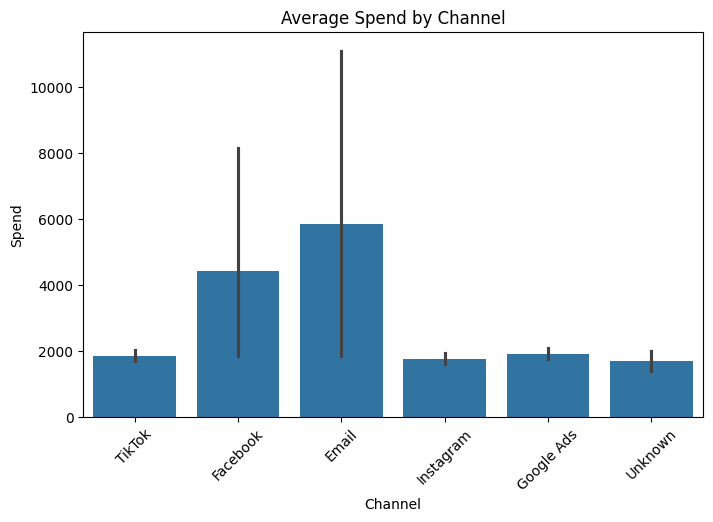

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x='Channel',
    y='Spend',
    estimator='mean'
)
plt.title('Average Spend by Channel')
plt.xticks(rotation=45)
plt.show()

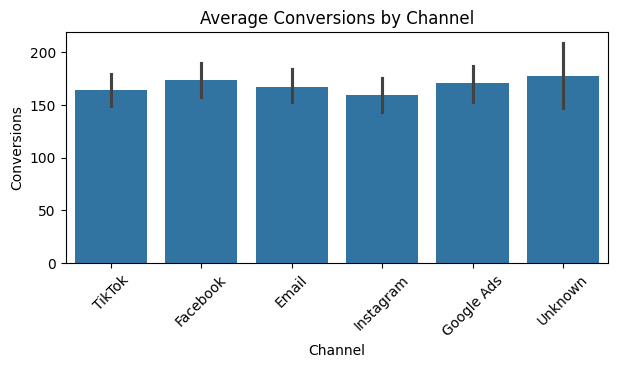

In [45]:
plt.figure(figsize=(7,3))
sns.barplot(
    data=df,
    x='Channel',
    y='Conversions',
    estimator='mean'
)
plt.title('Average Conversions by Channel')
plt.xticks(rotation=45)
plt.show()

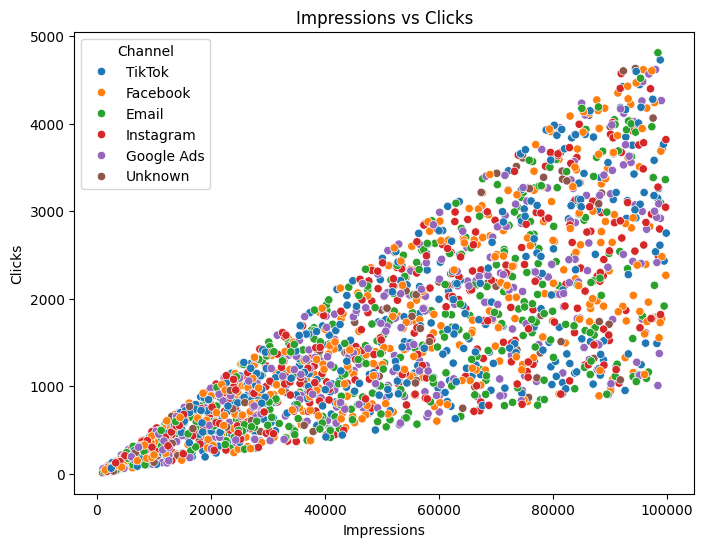

In [47]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Impressions',
    y='Clicks',
    hue='Channel'
)

plt.title('Impressions vs Clicks')
plt.show()

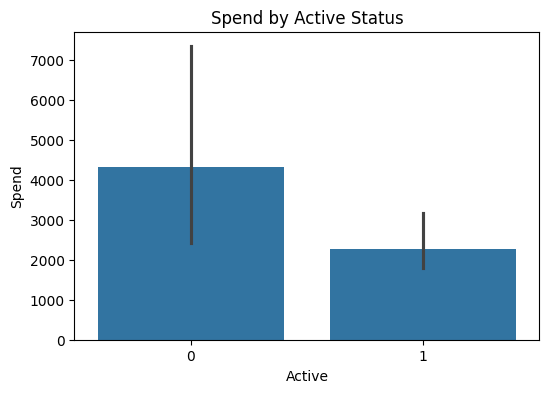

In [49]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='Active',
    y='Spend'
)

plt.title('Spend by Active Status')
plt.show()

In [50]:
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100

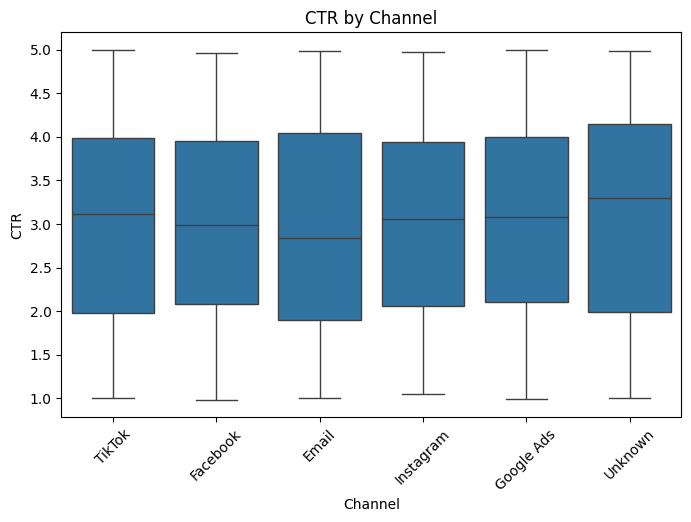

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Channel',
    y='CTR'
)

plt.title('CTR by Channel')
plt.xticks(rotation=45)
plt.show()

In [52]:
df['Conversion_Rate'] = (df['Conversions'] / df['Clicks']) * 100

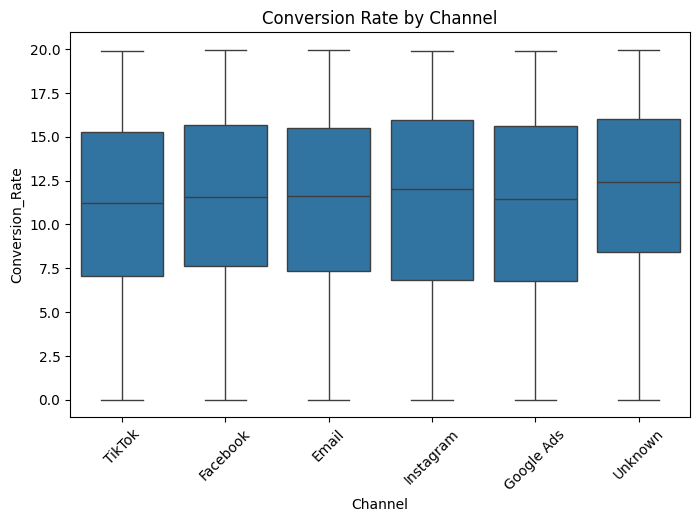

In [53]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Channel',
    y='Conversion_Rate'
)

plt.title('Conversion Rate by Channel')
plt.xticks(rotation=45)
plt.show()